# Exploratory Data Analysis (EDA) on Retail Sales Data
**Internship Project - Oasis Infobyte (Level 1)**  
**Author:** Aditya Halder (Data Analytics Intern)

---

### Project Overview
In this project, we perform a comprehensive Exploratory Data Analysis (EDA) on a retail sales dataset. The goal is to clean and preprocess the data, calculate descriptive statistics, analyze sales trends over time, identify customer demographic purchasing patterns, and extract actionable business insights to help the retail company make data-driven decisions.

### Key Concepts & Requirements
1. **Data Loading and Cleaning**: Load the dataset, handle missing values, check for duplicate records, and format data types.
2. **Descriptive Statistics**: Calculate summary metrics such as mean, median, mode, and standard deviation.
3. **Time Series Analysis**: Examine sales trends over weeks, months, and seasonal periods.
4. **Customer Demographics Analysis**: Study purchasing patterns based on age groups and gender.
5. **Product Category Analysis**: Analyze sales performance across different product categories.
6. **Data Visualization**: Create charts (line charts, bar charts, donut charts, heatmaps) using Matplotlib and Seaborn.



## 1. Setup and Libraries
Importing required libraries for data manipulation, analysis, and visualization.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Loading the Dataset
Loading the retail sales dataset using Pandas. Note that we are using relative paths since the notebook is located in the `Notebook` folder.


In [17]:
# Load the dataset
file_path = '../Dataset/Dataset 1.csv'
df = pd.read_csv(file_path)

# Display the first 5 records
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 3. Data Cleaning and Preprocessing
Before conducting analysis, we must inspect the dataset's shape, data types, missing values, and check for duplicate rows to ensure data quality and integrity.


In [18]:
# Inspect shape and basic information
print("Dataset Dimensions:", df.shape)
df.info()


Dataset Dimensions: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


### Check for Missing Values & Duplicates


In [19]:
# Check for missing values in all columns
print("Missing values per column:\n", df.isnull().sum())

# Check for duplicate transactions
duplicates_count = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicates_count}")


Missing values per column:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Number of duplicate records: 0


### Format Columns
We convert the `Date` column from object/string type to `datetime64` for time-series operations, and verify if the `Total Amount` is correct.


In [20]:
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Add month and year-month columns for time-series grouping
df['Year-Month'] = df['Date'].dt.to_period('M')
df['Day_of_Week'] = df['Date'].dt.day_name()

# Verify if Total Amount == Quantity * Price per Unit
is_correct = (df['Total Amount'] == df['Quantity'] * df['Price per Unit']).all()
print(f"Is Total Amount consistent across all records? {is_correct}")

df.head()


Is Total Amount consistent across all records? True


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year-Month,Day_of_Week
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,Friday
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,Monday
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,Friday
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,Sunday
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,Saturday


## 4. Descriptive Statistics
Generating basic statistical parameters (mean, median, mode, standard deviation, minimum, maximum) to summarize the distribution and central tendency of the numerical variables.


In [21]:
# Descriptive stats for numerical columns
df.describe()


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [22]:
# Value counts for categorical columns
print("Gender Breakdown:\n", df['Gender'].value_counts())
print("\nProduct Category Breakdown:\n", df['Product Category'].value_counts())


Gender Breakdown:
 Gender
Female    510
Male      490
Name: count, dtype: int64

Product Category Breakdown:
 Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


## 5. Time Series Analysis (Sales Trends over Time)
Let's analyze how sales fluctuate over time. We filter out the small tail of January 2024 to focus on the complete year of 2023 sales.


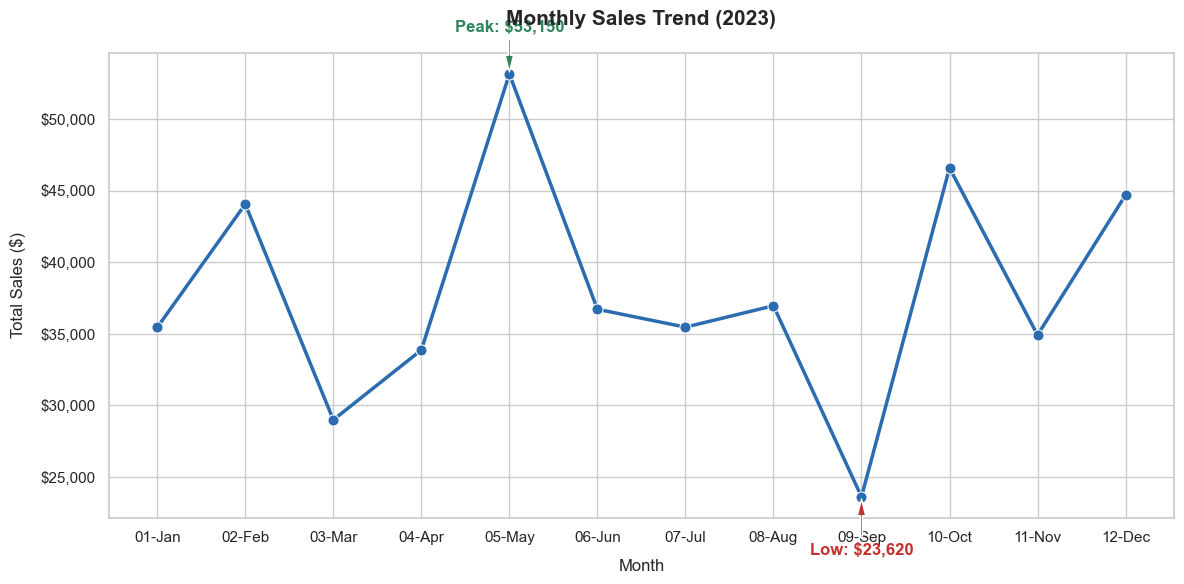

In [23]:
# Filter 2023 sales for monthly trend analysis
df_2023 = df[df['Date'].dt.year == 2023].copy()
df_2023['Month'] = df_2023['Date'].dt.strftime('%m-%b')

# Group by Month and sum Total Sales
monthly_sales = df_2023.groupby('Month')['Total Amount'].sum().reset_index()

# Plot Monthly Sales Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Month', y='Total Amount', marker='o', color='#2b6cb0', linewidth=2.5, markersize=8)

plt.title('Monthly Sales Trend (2023)', pad=20, weight='bold', fontsize=15)
plt.xlabel('Month', labelpad=10)
plt.ylabel('Total Sales ($)', labelpad=10)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')

# Annotate peak and low
peak_idx = monthly_sales['Total Amount'].idxmax()
peak_month = monthly_sales.loc[peak_idx, 'Month']
peak_val = monthly_sales.loc[peak_idx, 'Total Amount']
plt.annotate(f'Peak: ${peak_val:,.0f}', xy=(peak_month, peak_val), xytext=(peak_month, peak_val + 3000),
             arrowprops=dict(facecolor='#2f855a', shrink=0.05, width=1.5, headwidth=6),
             horizontalalignment='center', weight='bold', color='#2f855a')

low_idx = monthly_sales['Total Amount'].idxmin()
low_month = monthly_sales.loc[low_idx, 'Month']
low_val = monthly_sales.loc[low_idx, 'Total Amount']
plt.annotate(f'Low: ${low_val:,.0f}', xy=(low_month, low_val), xytext=(low_month, low_val - 4000),
             arrowprops=dict(facecolor='#c53030', shrink=0.05, width=1.5, headwidth=6),
             horizontalalignment='center', weight='bold', color='#c53030')

# Save visualization
plt.tight_layout()
plt.savefig('../Visualizations/sales_trend.png', dpi=300)
plt.show()


## 6. Category-wise Sales Analysis
Next, we analyze sales across different product categories: Beauty, Clothing, and Electronics.


In [24]:
# Group by Product Category
cat_sales = df.groupby('Product Category').agg(
    Transactions=('Transaction ID', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Sales=('Total Amount', 'sum'),
    Average_Price=('Price per Unit', 'mean')
).reset_index()

cat_sales


,Product Category,Transactions,Total_Quantity,Total_Sales,Average_Price
0,Beauty,307,771,143515,184.055375
1,Clothing,351,894,155580,174.287749
2,Electronics,342,849,156905,181.900585


### Visualizing Sales Distribution by Category (Donut Chart)


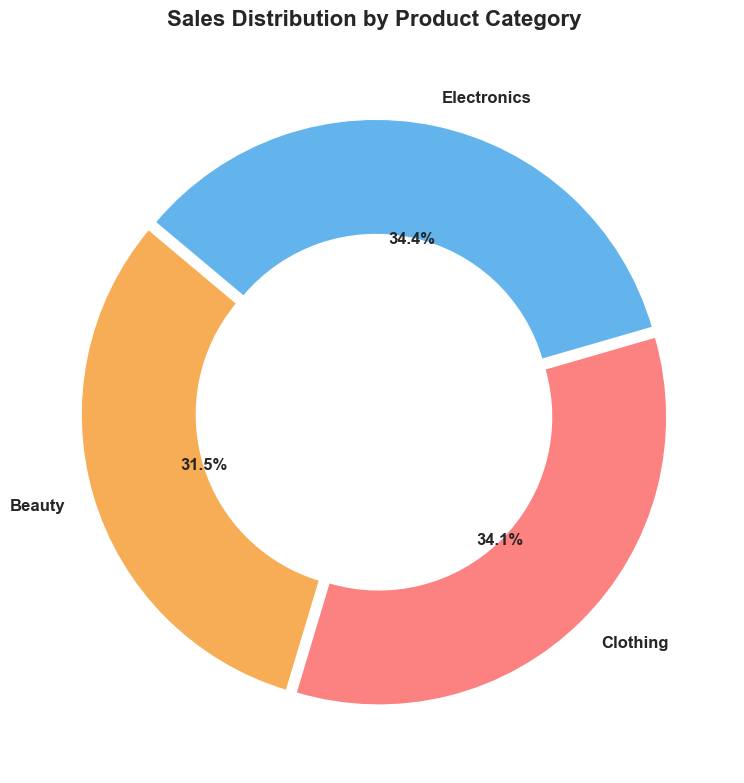

In [25]:
# Donut Chart for Product Categories
plt.figure(figsize=(8, 8))
colors = ['#f6ad55', '#fc8181', '#63b3ed']
explode = (0.02, 0.02, 0.02)

plt.pie(cat_sales['Total_Sales'], explode=explode, labels=cat_sales['Product Category'], 
        autopct='%1.1f%%', startangle=140, colors=colors, 
        textprops={'fontsize': 12, 'weight': 'bold'},
        wedgeprops=dict(width=0.4, edgecolor='w'))

plt.title('Sales Distribution by Product Category', pad=20, weight='bold', fontsize=16)

# Save chart
plt.tight_layout()
plt.savefig('../Visualizations/category_sales.png', dpi=300)
plt.show()


## 7. Customer Demographics and Purchasing Analysis
Let's analyze who are our top-selling consumer segments by looking at **Gender** and **Age Groups**.


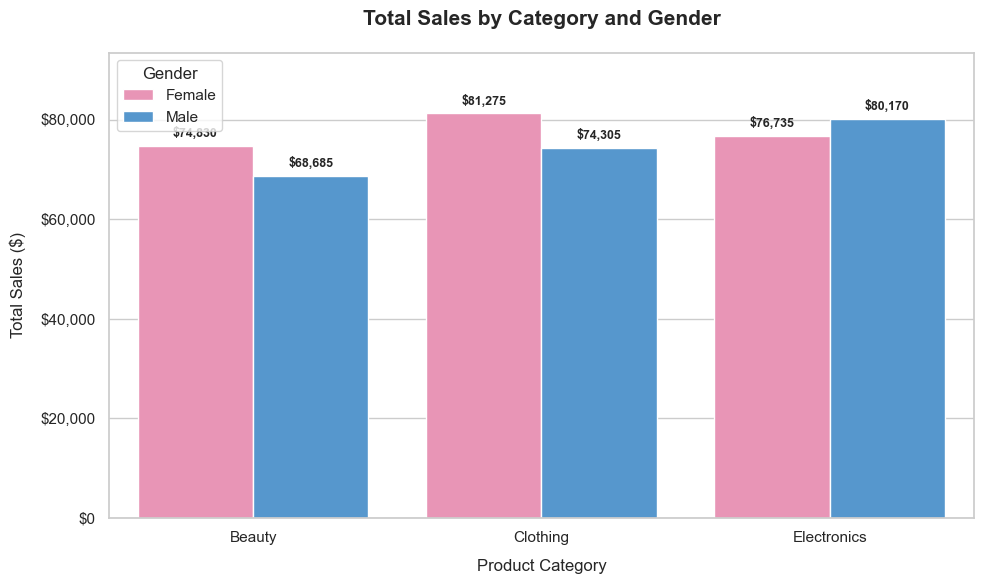

In [26]:
# Group by Category and Gender
cat_gender = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().reset_index()

# Plot Sales by Category and Gender
plt.figure(figsize=(10, 6))
sns.barplot(data=cat_gender, x='Product Category', y='Total Amount', hue='Gender', palette=['#f687b3', '#4299e1'])
plt.title('Total Sales by Category and Gender', pad=20, weight='bold', fontsize=15)
plt.xlabel('Product Category', labelpad=10)
plt.ylabel('Total Sales ($)', labelpad=10)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(title='Gender')

# Value labels on top of bars
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'${height:,.0f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=9, weight='bold')

plt.ylim(0, cat_gender['Total Amount'].max() * 1.15)
plt.tight_layout()
plt.savefig('../Visualizations/top_products.png', dpi=300)
plt.show()


### Purchasing Behavior by Age Groups
Binning customers into specific age cohorts (18-25, 26-35, 36-45, 46-55, 56-65) to reveal spending habits by demographic age groups.


In [27]:
# Bin customers by age
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Group by Age Group
age_group_analysis = df.groupby('Age Group', observed=False).agg(
    Transactions=('Transaction ID', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Sales=('Total Amount', 'sum'),
    Average_Spending=('Total Amount', 'mean')
).reset_index()

age_group_analysis


,Age Group,Transactions,Total_Quantity,Total_Sales,Average_Spending
0,18-25,149,366,74650,501.006711
1,26-35,203,522,97090,478.275862
2,36-45,207,533,96835,467.801932
3,46-55,225,578,97235,432.155556
4,56-65,216,515,90190,417.546296
5,65+,0,0,0,NaN


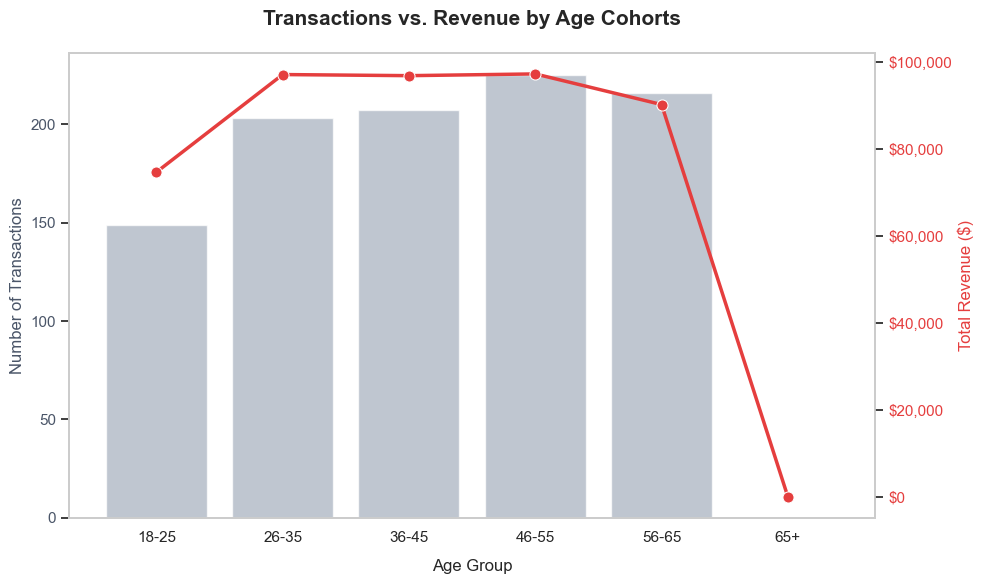

In [28]:
# Plot Sales and Transactions by Age Group
fig, ax1 = plt.subplots(figsize=(10, 6))

color = '#4a5568'
ax1.set_xlabel('Age Group', labelpad=10)
ax1.set_ylabel('Number of Transactions', color=color)
sns.barplot(data=age_group_analysis, x='Age Group', y='Transactions', color='#a0aec0', ax=ax1, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(False)

ax2 = ax1.twinx()  
color = '#e53e3e'
ax2.set_ylabel('Total Revenue ($)', color=color)
sns.lineplot(data=age_group_analysis, x='Age Group', y='Total_Sales', color=color, ax=ax2, marker='o', linewidth=2.5, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.yaxis.set_major_formatter('${x:,.0f}')
ax2.grid(False)

plt.title('Transactions vs. Revenue by Age Cohorts', pad=20, weight='bold', fontsize=15)
fig.tight_layout()
plt.show()


## 8. Correlation Analysis
Understanding correlations between customer Age, Quantity purchased, Unit Price, and the Total Amount spent.


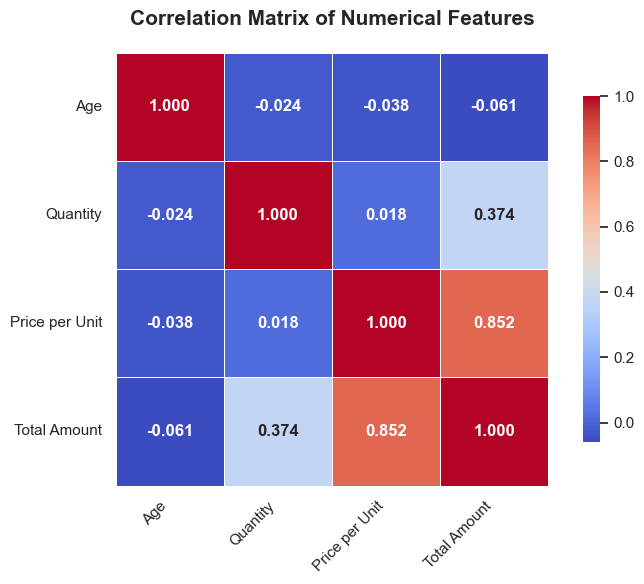

In [29]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5, 
            square=True, cbar_kws={"shrink": .8}, annot_kws={'size': 12, 'weight': 'bold'})

plt.title('Correlation Matrix of Numerical Features', pad=20, weight='bold', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../Visualizations/heatmap.png', dpi=300)
plt.show()


## 9. Key Insights and Business Recommendations

Based on our exploratory data analysis, here are the main takeaways:
1. **Sales Seasonality & Trends**:
   - The retail store generated a total of **$456,000** in sales across 1,000 transactions in 2023.
   - Sales peaked in **May 2023 ($53,150)** and **October 2023 ($46,580)**.
   - There was a significant drop in **September 2023 ($23,620)**. Retailers should plan targeted marketing campaigns, discounts, or inventory restocking before this annual slump.
2. **Category Performance**:
   - **Electronics** generated the highest overall sales (**$156,905**), despite having slightly fewer transactions than Clothing. This is driven by high-ticket items.
   - **Clothing** saw the highest volume of transactions (351) and quantity sold (894 units).
   - **Beauty** was the lowest contributor in revenue ($143,515), representing an opportunity for category expansion or promotions.
3. **Demographic Insights**:
   - **Gender Comparison**: Female customers spent slightly more overall (**$232,840**) compared to Male customers (**$223,160**). However, the average transaction size is almost identical (~$456).
   - **Gender & Product Affinity**: Female consumers spent significantly more on **Beauty** products ($83,860 vs. $59,655 for Males). Males spent more on **Electronics** ($84,650 vs. $72,255 for Females).
   - **Age Groups**: The **46-55** age group generated the most transactions (225) and revenue ($97,235), closely followed by the **26-35** and **36-45** brackets. The youngest group (**18-25**) had the highest average spend per transaction (**$501.01**).
4. **Correlation Results**:
   - **Total Amount** is highly correlated with **Price per Unit** (0.852) and moderately with **Quantity** (0.374).
   - Customer **Age** has zero correlation with purchasing behaviors (quantities, total spending, unit prices). This suggests product preferences and pricing limits are consistent across age brackets.

---
**End of Project**

